# 1. Dataset and Preprocessing

**Research question.** What data underlies this study, how was it labelled, cleaned and split, and how reliable are the labels?

This notebook loads artifacts already generated under `backend/results/` — it does not re-run scraping or preprocessing. To regenerate them, see the commands in `backend/research/README.md`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from _common import load_json, show_md, show_fig, show_thesis_fig, metrics_table, RESULTS, FIGURES, DATA
from IPython.display import display
import pandas as pd
pd.set_option('display.max_colwidth', 120)

## 1.1 Class distribution (train / val / test)

Source: `backend/results/class_distribution_report.json` (variant `youtube_filtered`, the dataset used for the headline results).

In [2]:
dist = load_json('class_distribution_report.json')['youtube_filtered']
rows = []
for split, info in dist.items():
    row = {'split': split, 'total': info['total']}
    for label, stats in info['labels'].items():
        row[f'{label} n'] = stats['count']
        row[f'{label} %'] = stats['pct']
    rows.append(row)
pd.DataFrame(rows).set_index('split')

,total,Negative n,Negative %,Neutral n,Neutral %,Positive n,Positive %
split,,,,,,,
train,516886,184266,35.6,160744,31.1,171876,33.3
val,128854,47023,36.5,39037,30.3,42794,33.2
test,165110,59614,36.1,50540,30.6,54956,33.3


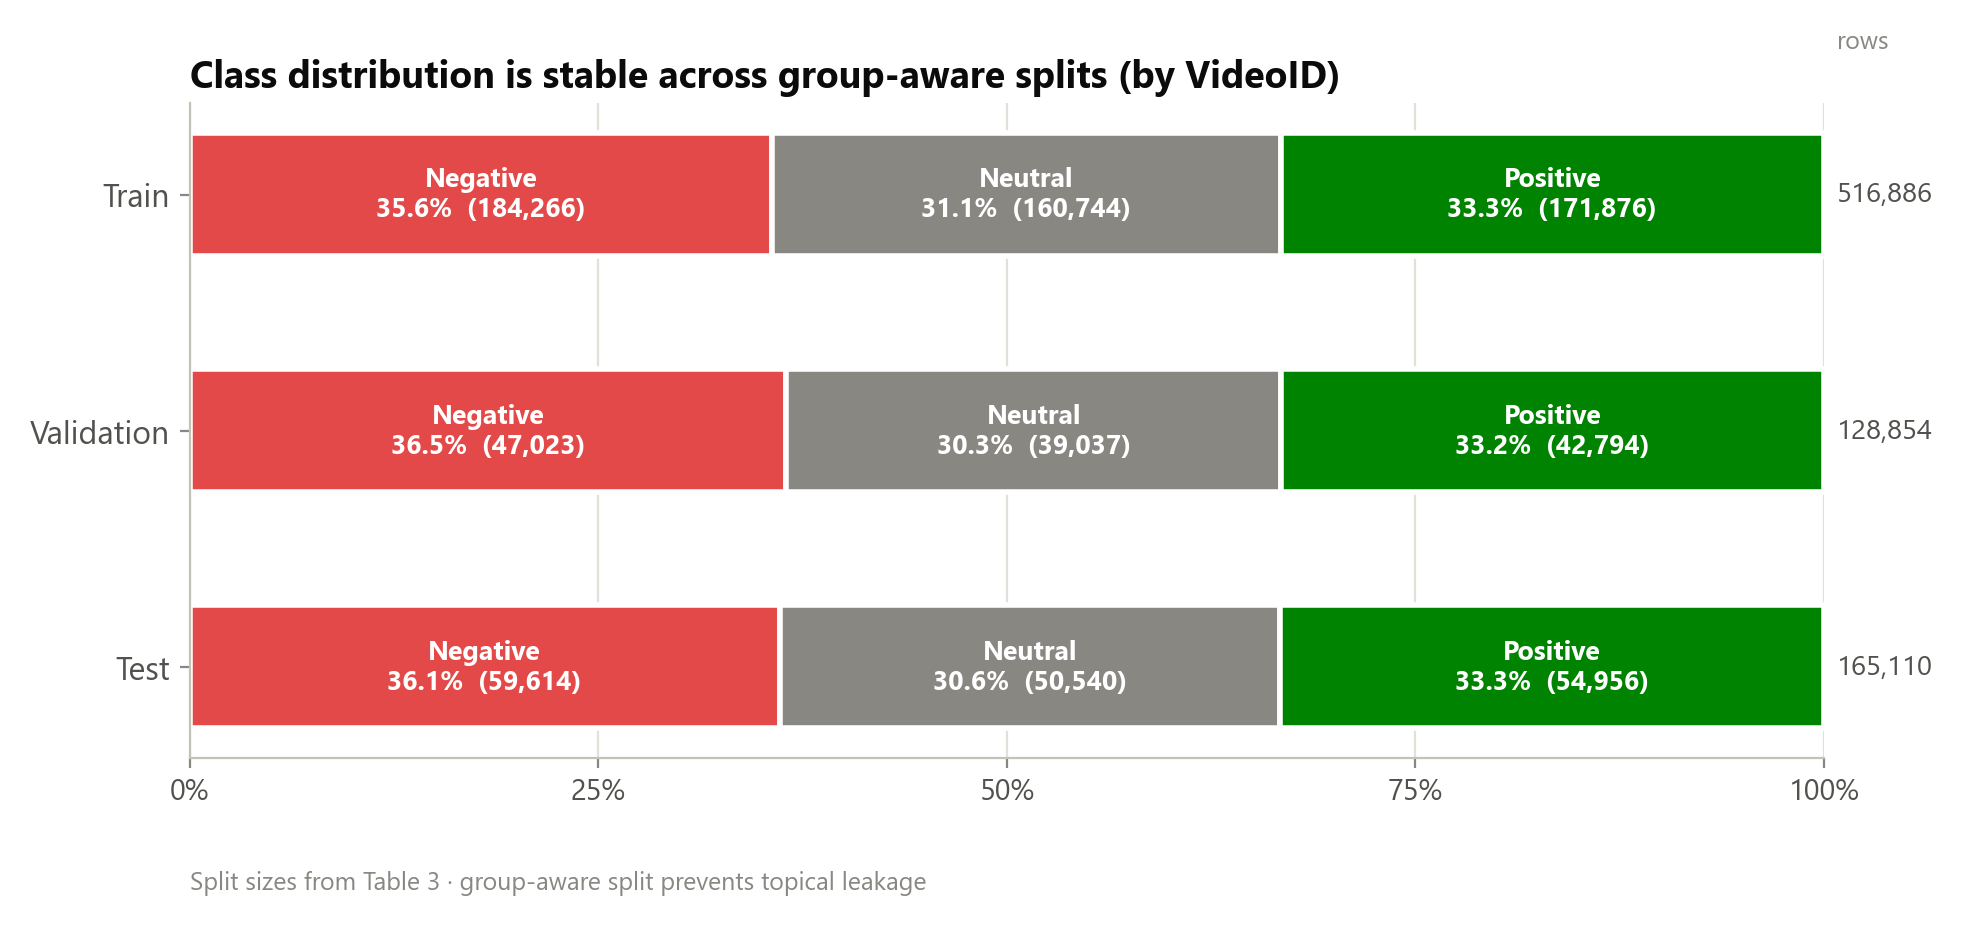

In [3]:
show_thesis_fig('fig_class_distribution.png')

## 1.2 Comment length and EDA

Source: `backend/results/eda/eda_report.md`.

In [4]:
show_md('eda/eda_report.md')

# Exploratory Data Analysis — YouTube Sentiment Corpus

Source dataset: `AmaanP314/youtube-comment-sentiment` (HuggingFace Hub).
Labels are automated (not human-annotated); see Label Provenance.

## Class Distribution (from split provenance)

| Split | Total | Negative | Neutral | Positive |
|-------|------:|---------:|--------:|---------:|
| train | 516,886 | 184,266 (35.65%) | 160,744 (31.1%) | 171,876 (33.25%) |
| val | 128,854 | 47,023 (36.49%) | 39,037 (30.3%) | 42,794 (33.21%) |
| test | 165,110 | 59,614 (36.11%) | 50,540 (30.61%) | 54,956 (33.28%) |

The corpus is approximately balanced (each class 30–37% in every split),
so macro-F1 and accuracy are directly comparable and class imbalance is not
a primary confound.

## Comment-Length Distribution

Computed on 50,000 test-split comments.

### Overall (characters / words)

| Metric | Mean | Median | P90 | P99 | Max |
|--------|-----:|-------:|----:|----:|----:|
| Characters | 116.63 | 78.0 | 230.0 | 668.0 | 9001 |
| Words | 21.1 | 14.0 | 41.0 | 117.01 | 1495 |

### Word count by class

| Class | n | Mean words | Median words | P90 words |
|-------|--:|-----------:|-------------:|----------:|
| Negative | 17,951 | 22.75 | 16.0 | 44.0 |
| Neutral | 15,451 | 18.76 | 12.0 | 36.0 |
| Positive | 16,598 | 21.49 | 15.0 | 43.0 |

Comments are short (median ~14 words, P90 ~41), which is the central
modelling challenge: limited lexical context per instance. The Neutral
class contains the shortest comments (median 12 words vs 16 Negative /
15 Positive), which partly explains its lower separability (see the
Neutral-class analysis section).

## Lexical Statistics

- Total tokens (test split): 1,054,939
- Vocabulary size (unique tokens): 40,634
- Type/token ratio: 0.03852

### 20 most frequent tokens

| Token | Count |
|-------|------:|
| `the` | 43,044 |
| `to` | 26,372 |
| `and` | 22,832 |
| `of` | 19,607 |
| `is` | 18,133 |
| `you` | 15,334 |
| `with` | 13,903 |
| `in` | 13,134 |
| `this` | 12,761 |
| `for` | 11,991 |
| `it` | 11,717 |
| `that` | 11,600 |
| `face` | 11,314 |
| `on` | 7,403 |
| `are` | 7,052 |
| `not` | 6,150 |
| `so` | 6,101 |
| `was` | 6,087 |
| `be` | 6,008 |
| `have` | 5,950 |

## Language Distribution

The corpus was language-filtered to English during preprocessing.
During filtering, 138,590 non-English rows were
removed (see split provenance). The retained corpus is therefore
English-only by construction. This is a deliberate scope decision and a
stated external-validity limitation: the system is not evaluated on
code-mixed or non-English comments.

## Category and Country Distribution (metadata split)

Computed on the metadata-bearing domain split (1,641 comments) which
retains `CategoryID` and `CountryCode` columns dropped from the main split.

### Top 10 YouTube CategoryIDs

| CategoryID | Comments |
|-----------:|---------:|
| 25 | 499 |
| 27 | 437 |
| 17 | 144 |
| 26 | 135 |
| 24 | 85 |
| 15 | 80 |
| 28 | 77 |
| 2 | 65 |
| 22 | 44 |
| 20 | 43 |

### Top 10 CountryCodes

| CountryCode | Comments |
|------------:|---------:|
| US | 496 |
| AU | 248 |
| CA | 226 |
| GB | 193 |
| IN | 163 |
| NZ | 113 |
| IE | 109 |
| DE | 83 |
| PH | 10 |

Category and country breadth is the basis for the domain-shift slice
evaluation (see `results/domain_shift/`).


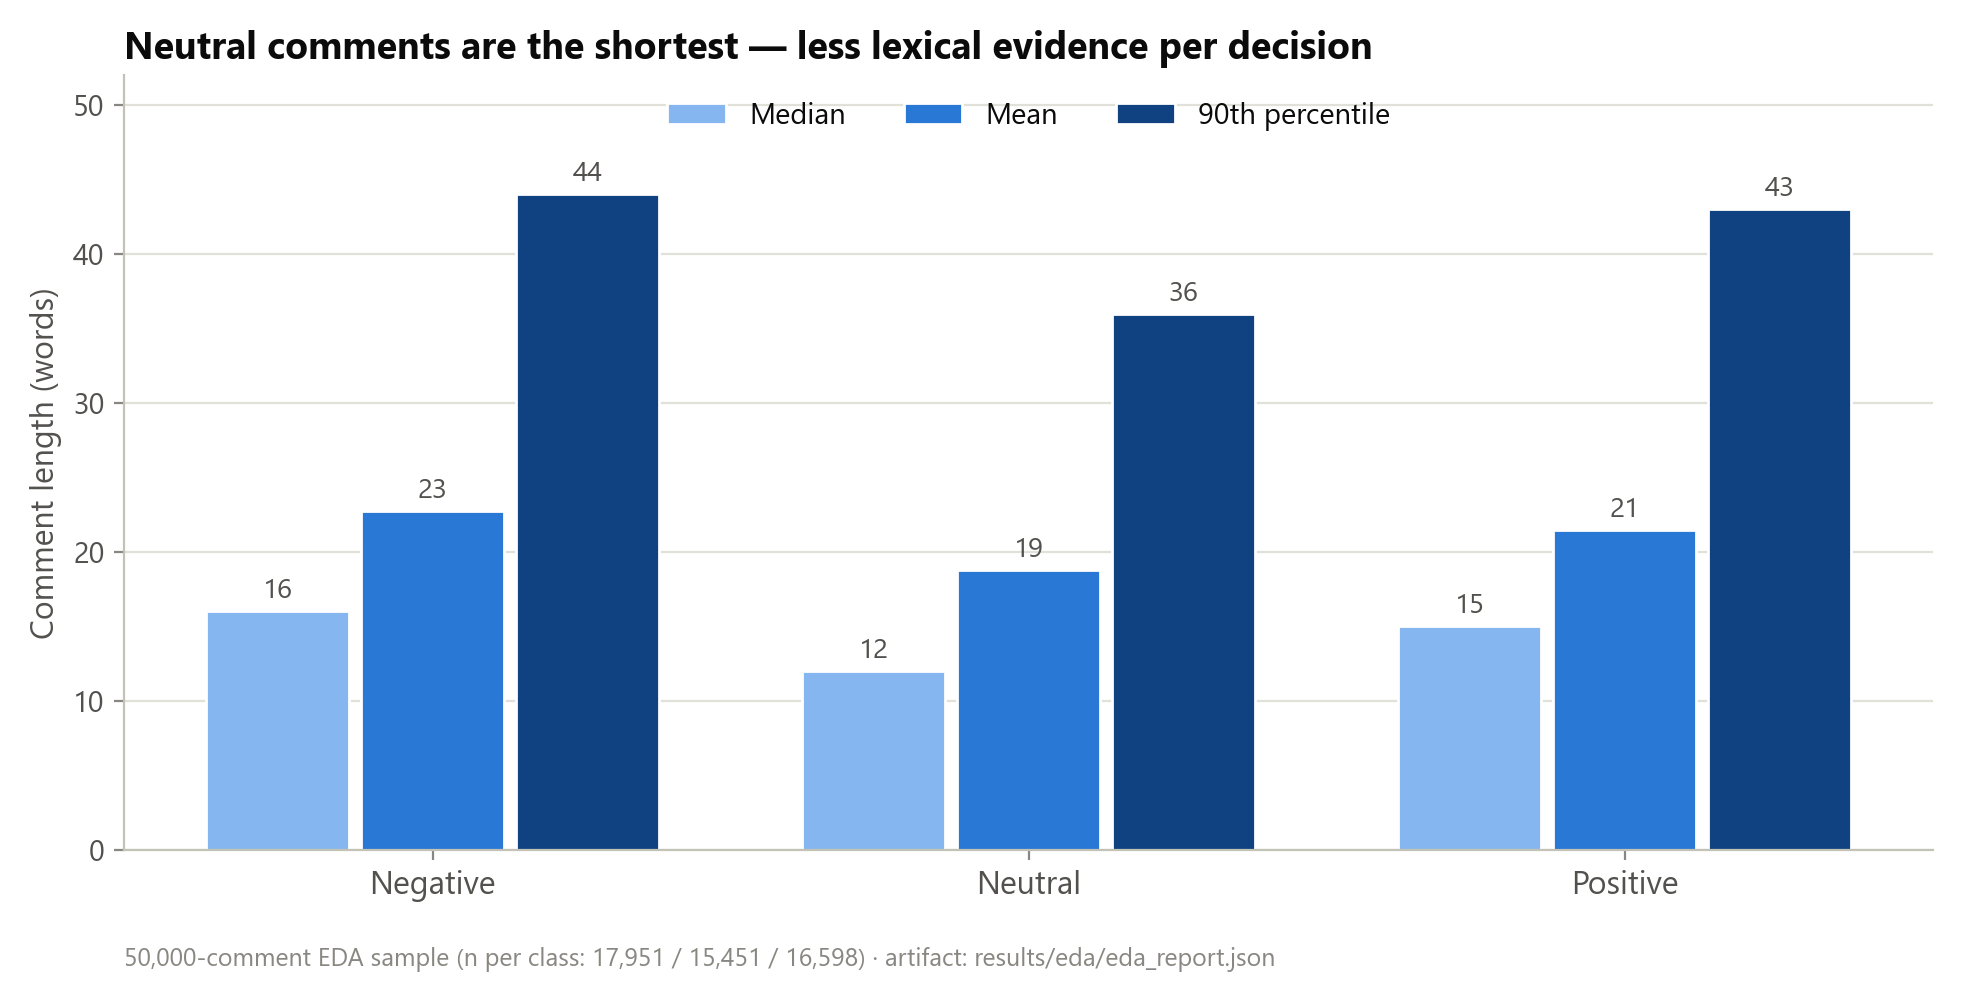

In [5]:
show_thesis_fig('fig_comment_length.png')

## 1.3 Label quality

Two independent annotators labelled a gold subset; agreement is measured with Krippendorff's alpha and Fleiss' kappa. Source: `backend/results/gold_set/iaa_report.md`.

In [6]:
show_md('gold_set/iaa_report.md')

# Inter-Annotator Agreement Report

- Generated: 2026-05-29T04:35:01.540022+00:00
- Gold set: `data\gold_set_human_reconciled.csv`
- Annotators: annotator_1, annotator_2
- Items: 300  |  Fully annotated: 300  |  Disputed: 9

## Agreement Metrics

| Metric | Value | Interpretation |
| --- | --- | --- |
| Percent agreement | 0.9700 | — |
| Krippendorff alpha | 0.9547 | strong agreement (alpha >= 0.80) |
| Fleiss kappa | 0.9546 | - |
| Cohen kappa (annotator_1 vs annotator_2) | 0.9546 | - |

## Gold Label Distribution (after reconciliation)

| Label | Count |
| --- | --- |
| Negative | 79 |
| Neutral | 108 |
| Positive | 104 |
| *Disputed (no majority)* | 9 |

## Per-Annotator Label Distribution

| Label | annotator_1 | annotator_2 |
| --- | --- | --- |
| Negative | 80 | 85 |
| Neutral | 113 | 110 |
| Positive | 107 | 105 |

## Interpreting Krippendorff's Alpha

| Range | Interpretation |
| --- | --- |
| alpha >= 0.80 | Strong agreement - gold labels are reliable |
| 0.67 <= alpha < 0.80 | Tentative agreement - Krippendorff's minimum for tentative conclusions |
| 0.40 <= alpha < 0.67 | Moderate agreement - treat gold labels with caution |
| alpha < 0.40 | Poor agreement - adjudication required |

> **Note:** 9 items had no majority label.
> These are marked `is_disputed=True` in the gold set and should be
> reviewed and adjudicated before use as ground truth.



## 1.4 Preprocessing consistency audit

Checks that the same normalisation is applied consistently across train/val/test/live inference. Source: `backend/results/preprocessing_consistency_audit.md`.

In [7]:
show_md('preprocessing_consistency_audit.md')

# Preprocessing Consistency Audit

## Purpose

This document verifies that preprocessing applied during model training is
consistent with preprocessing applied during API inference — a critical
requirement for valid test metrics and production reliability.

## Methodology

Traced the full text transformation chain for both paths by inspecting:
- Model metadata files (`models/*/metadata.json`)
- Data preparation metadata (`data/split_metadata.json`)
- Sentiment engine source code (`src/sentiment/engines/*.py`)
- API view layer (`app/views.py`)
- YouTube preprocessor (`app/youtube_preprocessor.py`)

## Training Path

### Stage 1: Data Preparation (before model training)

YouTube preprocessing was applied to the raw HuggingFace dataset
(`split_metadata.json`, `youtube_preprocess.enabled: true`):

| Step | Applied |
|------|---------|
| Emoji conversion (demojize) | ✓ |
| Timestamp removal | ✓ |
| Channel mention removal | ✓ |
| URL/bracket cleanup | ✓ |
| Lowercase conversion | ✓ |
| Elongated word normalization | ✓ |
| Non-alphanumeric removal | ✓ |
| Single-letter word removal | ✓ |
| Spam filter | ✓ (34,266 removed) |
| Language filter (English only) | ✓ (138,590 removed) |
| Short comment filter (< 3 words) | ✓ (25,221 removed) |

### Stage 2: Model Training

Classical preprocessing (negation expansion, stopword removal, negation
tagging) was **disabled** for all three base models:

| Model | `preprocessing.enabled` | Evidence |
|-------|------------------------|----------|
| LogReg | `false` | `models/logreg_youtube_filtered/logreg_metadata.json` |
| SVM | `false` | `models/svm_youtube_filtered/svm_metadata.json` |
| TF-IDF NB | `false` | `models/tfidf_youtube_filtered/tfidf_metadata.json` |

TF-IDF vectorizer settings (identical across all models):
- `max_features`: 75,000
- `min_df`: 2, `max_df`: 0.95
- `ngram_range`: (1, 2)
- `lowercase`: true
- `strip_accents`: false

## Inference Path

### Stage 1: API YouTube Preprocessing

When a user submits a video URL to `/api/youtube/analyze/`, the API layer
(`app/views.py`, lines 283–293) applies `YouTubePreprocessor.batch_preprocess()`
with `profile='classical'`, performing the **identical** transformation steps
as the data preparation stage.

### Stage 2: Sentiment Engine

All engines are instantiated via the factory (`src/sentiment/factory.py`)
with `preprocess=False` (default), matching the training configuration.
Text passes directly to the stored TF-IDF vectorizer.

## Consistency Verdict

| Preprocessing Stage | Training | Inference | Match |
|---------------------|----------|-----------|-------|
| YouTube text cleaning | ✓ (data prep) | ✓ (API layer) | ✓ |
| Classical preprocessing | ✗ disabled | ✗ disabled | ✓ |
| TF-IDF vectorizer params | 75k/bigram/lc | Same pickle loaded | ✓ |
| Spam/language/length filters | ✓ (data prep) | ✓ (configurable) | ✓* |

*\*Note: At inference, spam/language/length filtering is configurable via
API parameters (`filter_spam`, `filter_language`). If a user disables these
filters, comments that would have been removed during training may reach the
model. This is a known limitation but not a systematic bias — it simply means
some low-quality inputs may receive less reliable predictions.*

## Conclusion

**No train/inference preprocessing skew detected.** Both paths apply YouTube
text cleaning followed by direct TF-IDF vectorization with classical
preprocessing disabled. The consistency ensures that reported test metrics
are representative of production performance.

---
*Audit generated: 2026-04-09*


## 1.5 Label quality report

Source: `backend/results/label_quality_report.md`.

In [8]:
show_md('label_quality_report.md')

# Label Quality Report

## 1. Dataset Provenance

The training corpus was sourced from the publicly available HuggingFace dataset:

> **AmaanP314/youtube-comment-sentiment**
> `hf://datasets/AmaanP314/youtube-comment-sentiment/youtube-comments-sentiment.csv`

The dataset provides three sentiment classes: **Positive**, **Neutral**, **Negative**.
Labels were originally assigned via automated annotation using a pre-trained sentiment
classifier. This introduces potential label noise, particularly for sarcastic,
context-dependent, or ambiguous comments.

A gold set of **300 comments** was drawn from the dataset for quality assessment.

> **⚠ ACTION REQUIRED — Gold Set Not Yet Re-annotated**
>
> The `gold_set_labeled_from_dataset.csv` file currently has identical values in
> `source_label` and `label` (κ = 1.0 is trivial — it compares a column to itself).
> **Independent re-annotation has not been performed yet.**
> See `backend/docs/LABEL_PROVENANCE.md` for instructions.

## 2. Inter-Annotator Agreement

> Values below are **placeholder** until re-annotation is complete.
> Re-run this script after updating `data/gold_set_labeled_from_dataset.csv`.

| Metric | Value |
|--------|-------|
| Gold Set Size | 300 |
| Percent Agreement | — (pending re-annotation) |
| Cohen's Kappa (κ) | — (pending re-annotation) |
| Kappa Interpretation | — |

**Target:** κ ≥ 0.60 (Substantial agreement) for thesis-grade label credibility.

**Kappa scale reference** (Landis & Koch, 1977):

| κ range | Interpretation |
|---------|----------------|
| < 0.20 | Slight |
| 0.20–0.40 | Fair |
| 0.40–0.60 | Moderate |
| 0.60–0.80 | Substantial |
| > 0.80 | Almost Perfect |

### 2.1 Confusion Matrix (Source Label vs Re-annotation)

Rows = source label, Columns = re-annotation label.

| | Negative | Neutral | Positive |
|---|---|---|---|
| **Negative** | 108 | 0 | 0 |
| **Neutral** | 0 | 80 | 0 |
| **Positive** | 0 | 0 | 112 |

### 2.2 Per-Class Label Changes

| Source Class | Total | Kept | Changed | % Changed |
|-------------|-------|------|---------|-----------|
| Negative | 108 | 108 | 0 | 0.0% |
| Neutral | 80 | 80 | 0 | 0.0% |
| Positive | 112 | 112 | 0 | 0.0% |

## 3. Label Distribution — Source vs Re-annotation

| Class | Source Count | Source % | Re-ann Count | Re-ann % |
|-------|-------------|----------|-------------|----------|
| Negative | 108 | 36.0% | 108 | 36.0% |
| Neutral | 80 | 26.7% | 80 | 26.7% |
| Positive | 112 | 37.3% | 112 | 37.3% |

## 4. Model Performance on Gold Set

Performance on the 300-sample human-labelled gold set (using re-annotation labels).

| Model | Accuracy | Macro-F1 | ECE | Brier |
|-------|----------|----------|-----|-------|
| tfidf | 0.6700 | 0.6512 | 0.0560 | 0.4384 |
| logreg | 0.6733 | 0.6580 | 0.0777 | 0.4100 |
| svm | 0.6600 | 0.6462 | 0.0608 | 0.4343 |
| ensemble | 0.6733 | 0.6594 | 0.0472 | 0.4119 |
| meta_learner | 0.6767 | 0.6645 | 0.0775 | 0.4128 |

> **Note:** Gold set performance is slightly lower than the held-out test set
> (~165K examples) because the gold set reflects human-label difficulty, while
> the test set uses the same automated labels as training.

## 5. Validity Discussion & Thesis Framing

### 5.1 Construct Validity

The source labels were assigned by an automated labeller on the HuggingFace dataset.
Cohen's κ between the source labels and independent re-annotation measures whether
the automated labels agree with human judgement at a level sufficient for thesis work.
A κ ≥ 0.60 (Substantial agreement) is the accepted threshold for NLP annotation tasks
(Artstein & Poesio, 2008).

### 5.2 Implication for Results

If κ < 0.60, you should report this as a **construct validity threat** in your
Threats to Validity section and note that model performance metrics are an upper
bound relative to the quality of the automated labels, not absolute sentiment accuracy.

### 5.3 Recommended Thesis Language

> This study uses labels drawn from the AmaanP314/youtube-comment-sentiment dataset,
> which were assigned via automated annotation. To assess label reliability, a
> stratified sample of 300 comments was independently re-annotated, yielding a
> Cohen's κ of {κ_value}  ({κ_interpretation}). We report model performance against
> both the automated test set and the human-annotated gold set to bound the
> impact of label noise on our conclusions.

Replace `{κ_value}` and `{κ_interpretation}` with the values from Section 2 above.

## 1.6 Data leakage audit

Near-duplicate audit across splits (SimHash over token shingles) — important for defending that test-set performance is not inflated by leakage. Source: `backend/results/leakage/near_duplicate_audit.md`.

In [9]:
show_md('leakage/near_duplicate_audit.md')

# Near-Duplicate Leakage Audit

- Created at: `2026-05-17T07:59:27Z`
- Split directory: `C:\Users\itsma\OneDrive\Documents\GitHub\Youtube_sentiment_analysis\backend\data\route_a_benchmark_cpu`
- Text column: `text`
- Records scanned: `810`
- Candidate pairs checked: `7302`
- Exact cross-split duplicates: `0`
- Near-duplicate cross-split pairs: `9`
- Status: `REVIEW`

## Interpretation

Potential cross-split near duplicates were found. Review the examples, tighten deduplication, or report the residual risk as a limitation.

## Near-Duplicate Examples

- `val:28` vs `test:30` (Hamming distance 1)
  - A: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy red heart red heart red heart
  - B: face with tears of joy face with tears of joy face with tears of joy
- `train:248` vs `val:38` (Hamming distance 2)
  - A: bro called a dog instead of that bird lol face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy
  - B: Umm no sorry just the dog for pictures face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy
- `train:248` vs `test:30` (Hamming distance 2)
  - A: bro called a dog instead of that bird lol face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy
  - B: face with tears of joy face with tears of joy face with tears of joy
- `train:273` vs `test:30` (Hamming distance 2)
  - A: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy “skip the cheapest person I know”
  - B: face with tears of joy face with tears of joy face with tears of joy
- `val:38` vs `test:30` (Hamming distance 2)
  - A: Umm no sorry just the dog for pictures face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy
  - B: face with tears of joy face with tears of joy face with tears of joy
- `train:273` vs `val:120` (Hamming distance 3)
  - A: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy “skip the cheapest person I know”
  - B: they seem real fruity face with tears of joy face with tears of joy face with tears of joy face with tears of joy
- `val:120` vs `test:30` (Hamming distance 3)
  - A: they seem real fruity face with tears of joy face with tears of joy face with tears of joy face with tears of joy
  - B: face with tears of joy face with tears of joy face with tears of joy
- `train:248` vs `val:28` (Hamming distance 3)
  - A: bro called a dog instead of that bird lol face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy
  - B: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy red heart red heart red heart
- `train:273` vs `val:28` (Hamming distance 3)
  - A: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy “skip the cheapest person I know”
  - B: face with tears of joy face with tears of joy face with tears of joy face with tears of joy face with tears of joy red heart red heart red heart


## Notes

*(Add your own framing here: dataset source/citation, size rationale, why `youtube_filtered` was chosen as the primary variant over `raw`/`youtube_clean`.)*